In [6]:
import torch
import torchvision
#import ttach as tta
import torch.nn as nn
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, ToTensor
from model.explainability import inference

import os
import sys

import copy
from skimage.transform import resize
from sklearn.cluster import AgglomerativeClustering
#from scipy.special import softmax

import torch.backends.cudnn as cudnn
#cudnn.benchmark = True

#import model.transformer
#import model.trainer as trainer
#import utils.datasets
import utils.utils
#import utils.plots as plots
#import utils.counting as counting

import numpy as np
import random
#import warnings
from matplotlib import pyplot as plt

#import utils.anchors
import cv2

import time
import pandas as pd

#from PIL import Image
#from PIL import ImageDraw
#from PIL import ImageFont
import rasterio as rio
import json

import gc
from explainability_generator import LRP

#root = '/home/a01328525/'
root = 'E:/Experiments/'

## Visualization tile explainability

In [2]:
def preprocess_image(img: np.ndarray) -> torch.Tensor:
    preprocessing = Compose([
        ToTensor(),
        #Normalize(mean=mean, std=std)
    ])
    return preprocessing(img.copy()).unsqueeze(0)

# Image Pre-processing function for ViT  
def img_to_tensor(img_path):
  rgb_img =plt.imread(img_path)
  rgb_img =rgb_img[...,::-1][:, :, ::-1]
  #rgb_img = cv2.imread(img_path, 1)[:, :, ::-1]
  rgb_img = cv2.resize(rgb_img, (224, 224))
  rgb_img = np.float32(rgb_img) / 255
  input_tensor = preprocess_image(rgb_img, mean=[0.5, 0.5, 0.5],std=[0.5, 0.5, 0.5])
  return input_tensor

(224, 224, 3)
0.06988475 1.0598137


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06988475..1.0598137].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

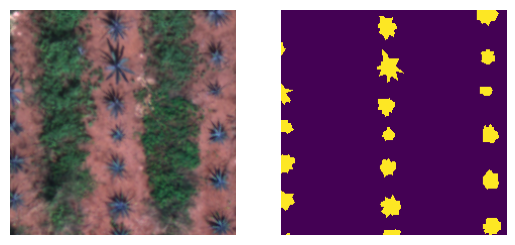

In [3]:
device='cuda'
#import rasterio as rio
from tifffile import imread

#image_path = root+"/Datasets Tiles/Zone3/0182.tif" #3 plants
#image_path = root+"/Datasets Tiles/Zone3/0223.tif" #
#image_path = root+"/Datasets Tiles/Zone3/0381.tif" #
#image_path = root+"/Datasets Tiles/Zone3/0387_bgr.tif" #two plants
#image_path = root+"/Datasets Tiles/Zone3/0287.tif" #4 plants
image_path = root+"/Datasets Tiles/Zone108_octubre/5324.tif"
#image_path = root+"/Datasets Tiles/Zone3/0706.tif" #multiple plants
#image_path = root+"/Datasets Tiles/Zone102_part1/7429.tif"
        
#with rio.open(image_path) as img :
#    image = img.read()
image = imread(image_path)
gt_mask = image[...,8]
image = image[...,0:3]
print(image.shape)
print(image.min(), image.max())

zone_name='Zone3'
f = open(root+'zone_parameters.json')
zone_parameters = json.load(f)
f.close()
#correctionRGB = zone_parameters[zone_name]['correctionRGB']
#image = image/correctionRGB
#print(image.min(), image.max())

image = preprocess_image(image).to(device).requires_grad_(True)
image_plot = image[0].permute(1, 2, 0)[:,:,[2, 1, 0]].detach().cpu(); #image_plot = image_plot/image_plot.max()

plt.subplot(1, 2, 1)
plt.imshow(image_plot)
plt.axis('off')
#plt.savefig("rgb.png", dpi=300)
plt.subplot(1, 2, 2)
plt.imshow(gt_mask)
plt.axis('off')

In [4]:
#folder_maps = root+'Datasets Maps/'
#folder_tiles = root+'Datasets Tiles/'
#folder_save_results = root+'Counting results/'
folder_trained_models = root+"Datasets_STED/runs_transformers/"
#model_dir = folder_trained_models+"STED_100_nano_bbox_bgr_diou_BitNet/best.pt"
model_dir = folder_trained_models+"STED_5_nano_cbbox_bgr_diou_BitNet/best.pt"
model_dir = folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt"

img_size = 224
N_channels = 3
n_model = 128
num_blks = 1
conf_thr = 0.3 #filter scores to consider only predictions with confidence score greater than conf_thr
iou_thr = 0.5#0.15# using diou #0.5
diou_thr = 0.5#0.15# using diou #0.5
obj='cbbox'
device='cuda'
bitNet = True

In [7]:
import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)

checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )
boxes, scores, tokens, adjusts, masks  = inference(model, image, obj, conf_thr, diou_thr, device=device)
print(tokens)
for blk in model.encoder1.blks:
    blk.attention.clean_hooks()
for blk in model.encoder2.blks:
    blk.attention.clean_hooks()
model.cpu()
del model
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

[tensor([[ 12],
        [ 20],
        [ 28],
        [ 32],
        [ 48],
        [ 76],
        [ 98],
        [104],
        [126],
        [132],
        [152],
        [154],
        [361],
        [476],
        [501],
        [641],
        [881],
        [950],
        [965]], device='cuda:0'), tensor([])]
Allocated: 68.49 MB
Reserved: 110.00 MB


In [8]:
import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)

checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )
print("Model loaded")

Model loaded


In [9]:
toks = np.array(tokens[0].detach().cpu()).reshape(-1)
toks

C:\Users\diego\AppData\Local\Temp\ipykernel_21192\1576112764.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  toks = np.array(tokens[0].detach().cpu()).reshape(-1)


array([ 12,  20,  28,  32,  48,  76,  98, 104, 126, 132, 152, 154, 361,
       476, 501, 641, 881, 950, 965])

In [10]:
attribution_generator = LRP(model)

In [11]:
cam  = attribution_generator.generate_LRP(image, toks)
print("OUTPUT ", cam.shape)

OUTPUT  torch.Size([1, 784])


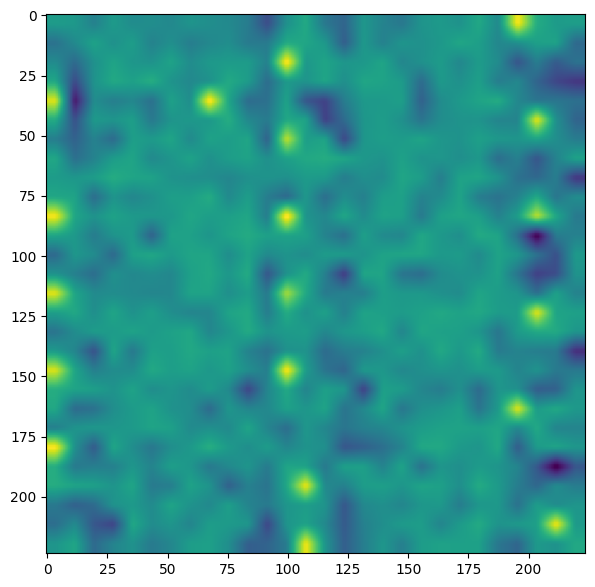

In [13]:
plt.figure(figsize=(7, 7))
#res = cam_f[0].detach().cpu().permute(1, 0).reshape(-1, 28, 28)
transformer_attribution = cam.detach().cpu().permute(1, 0)
#transformer_attribution = transformer_attribution.reshape(1, 1, 14, 14)
transformer_attribution = transformer_attribution.reshape(1, 1, 28, 28)
transformer_attribution = torch.nn.functional.interpolate(transformer_attribution, scale_factor=8, mode='bilinear')
transformer_attribution = transformer_attribution.reshape(224, 224).data.cpu().numpy()
transformer_attribution = (transformer_attribution - transformer_attribution.min()) / (transformer_attribution.max() - transformer_attribution.min())

plt.imshow(transformer_attribution)

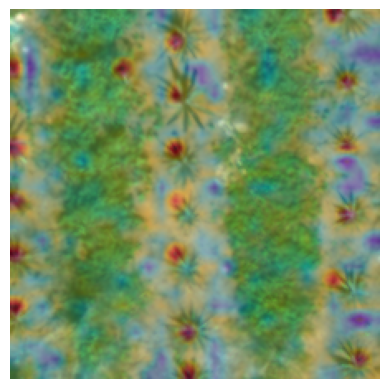

In [15]:
# create heatmap from mask on image
def show_cam_on_image(img, mask):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = 0.45*heatmap + np.float32(img)
    cam = cam / np.max(cam)
    return cam
    
image_transformer_attribution = image[0].permute(1, 2, 0).data.cpu().numpy()
image_transformer_attribution = (image_transformer_attribution - image_transformer_attribution.min()) / (image_transformer_attribution.max() - image_transformer_attribution.min())
vis = show_cam_on_image(image_transformer_attribution, transformer_attribution)
vis =  np.uint8(255 * vis)
vis = cv2.cvtColor(np.array(vis), cv2.COLOR_RGB2BGR)

plt.imshow(vis);
plt.axis('off');

## Evaluate explianability metrics

In [14]:
from model.explainability import deletion_auc
from model.explainability import insertion_auc
from model.explainability import pointing_game_circle
from model.explainability import topk_localization

In [7]:
import model.trainer as trainer

folder_bboxes = root+'/Datasets_STED/Zones_cbbox_dataset_01/'
#folder_bboxes = '/home/a01328525/Datasets_YOLO/Zones_cbbox_dataset_full_10/'
#folder_cbboxes = '/home/a01328525/Datasets_YOLO/Zones_cbboxes_dataset_03/' 
#folder_bboxes = root+'Datasets_STED/Zones_cbbox_dataset_features_10/'

obj = 'cbbox'
dataloader, test_dataloader = trainer.get_dataloaders(folder_bboxes, obj, augment=False, prob=0, batch_size=1, 
                                                      extract_masks=True, n_channels=3)


Load train data with 3026 images
Load val data with 1377 images


In [7]:
def explain_chefer(model_dir, image, tokens):
   
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
                
    attribution_generator = LRP(model)
    
    if len(tokens)>0:
        cam  = attribution_generator.generate_LRP(image, toks, method='transformer_attribution')
        #cam  = attribution_generator.generate_LRP(image, toks, method='rollout')
        transformer_attribution = cam.detach().cpu().permute(1, 0)
        #transformer_attribution = transformer_attribution.reshape(1, 1, 14, 14)
        transformer_attribution = transformer_attribution.reshape(1, 1, 28, 28)
        transformer_attribution = torch.nn.functional.interpolate(transformer_attribution, scale_factor=8, mode='bilinear')
        transformer_attribution = transformer_attribution.reshape(224, 224).data.cpu().numpy()
        result = torch.tensor((transformer_attribution - transformer_attribution.min()) / (transformer_attribution.max() - transformer_attribution.min()))

    else:
        result = torch.zeros(224, 224)
        
    model.cpu()
    del model
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    return result

In [12]:
#file_name = 'Rollout_Metrics_DA.csv'
file_name = 'Chefer_Metrics_DA.csv'
try:
    df = pd.read_csv(file_name)
    del_aucs = list(df['Deletion'])
    ins_aucs = list(df['Insertion'])
    poi_gams = list(df['Pointing Game'])
    ene_pois = list(df['Energy Pointing Game'])
    topk_ints = list(df['Top-k Inter'])
    times = list(df['Times'])
except:
    print("No file found!")
    del_aucs = []
    ins_aucs = []
    poi_gams = []
    ene_pois = []
    topk_ints = []
    times = []
print(len(del_aucs))
model_dir = folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt"

1377


In [10]:
it = 0
print(model_dir)
for i in test_dataloader:
    it+=1
    if it <=len(del_aucs):
        continue
    P, imgs, targets, masks =  i
    
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
    #print("Model loaded")

    imgs = imgs.to(device)
    boxes, scores, tokens, adjusts, _  = inference(model, imgs, obj, conf_thr, diou_thr, device=device)
    ###############################################################

    arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
    if arr.ndim > 0:
        toks = arr.tolist() 
    else: 
        toks = [int(arr)]
    
    start = time.perf_counter()
    results = explain_chefer(model_dir, imgs, toks)
    end = time.perf_counter()
    
    del_auc = deletion_auc(model, imgs, results, tokens[0], boxes[0], expanded_box=1.4)
    ins_auc = insertion_auc(model, imgs, results, tokens[0], boxes[0], expanded_box=1.4)
    poi_gam = pointing_game_circle(results, boxes[0], masks, expanded_box=1.4)
    ene_poi = energy_pointing(results, masks[0,0,...])
    topk_int = topk_localization(results, boxes[0], masks[0,0,...], expanded_box=1.4)
    
    del_aucs.append(del_auc)
    ins_aucs.append(ins_auc)
    poi_gams.append(poi_gam)
    ene_pois.append(ene_poi)
    topk_ints.append(topk_int)
    times.append(end-start)
    
    print('\r', "Image:%4d"%(it), end='')
    if it==150:
        break
    if it%10==0:
        print()
        print(np.array(del_aucs).mean(), np.array(ins_aucs).mean(), np.array(poi_gams).mean(), np.array(ene_pois).mean(), np.array(times).mean())

        # Create the DataFrame using a dictionary
        df = pd.DataFrame({
            'Deletion': np.array(del_aucs),
            'Insertion': np.array(ins_aucs),
            'Pointing Game': np.array(poi_gams),
            'Energy Pointing Game': np.array(ene_pois),
            'Top-k Inter': np.array(topk_ints),
            'Times': np.array(times)
        })
        df.to_csv(file_name)
    model.cpu()
    del model
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    
del_aucs = np.array(del_aucs)
ins_aucs = np.array(ins_aucs)
poi_gams = np.array(poi_gams)
ene_pois = np.array(ene_pois)
topk_ints = np.array(topk_ints)
times = np.array(times)

print()
print(del_aucs.mean(), ins_aucs.mean(), poi_gams.mean(), ene_pois.mean(), times.mean())

# Create the DataFrame using a dictionary
df = pd.DataFrame({
    'Deletion': del_aucs,
    'Insertion': ins_aucs,
    'Pointing Game': poi_gams,
    'Energy Pointing Game': ene_pois,
    'Top-k Inter': topk_ints,
    'Times': times
})
df.to_csv(file_name)

/home/a01328525/Datasets_STED/runs_transformers/explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt


/home/a01328525/anaconda3/lib/python3.9/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


 Image:1220
0.21749388926402954 0.7192205694549885 0.8138881501780236 0.15433854378343048 0.37765006714505667
 Image:1230
0.2176357956951469 0.7190141852733081 0.8134493312327828 0.15433459875918917 0.37725111798940475
 Image:1240
0.2175066010095179 0.719072761500795 0.8138195031530883 0.15427271754160937 0.37694576688706993
 Image:1250
0.21771396791040898 0.7188635567605496 0.8131889471278635 0.15468249838720255 0.37659812921437325
 Image:1260
0.21836648540541767 0.7187137347306051 0.81299036332659 0.15492202973373168 0.3763462327420379
 Image:1270
0.2179261803891011 0.7190625462417058 0.8127719857433602 0.15450596059778124 0.3761640486747759
 Image:1280
0.2177311367733637 0.7193002495390829 0.8125757320668614 0.15423975722074096 0.37591358997809854
 Image:1290
0.21829390848965147 0.7188903211103391 0.8130848837758082 0.1540173706489853 0.3757717401278808
 Image:1300
0.21831940925751742 0.7189499436146938 0.8130050965975889 0.15383572234696202 0.3757259118330497
 Image:1310
0.21860208